In [2]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/gaussian"
TOP_K = 10  # 上位k行で平均

def extract_gaussian(path):
    m = re.search(r"gaussian([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []

for unit in units:
    pattern = f"{base_path}/unit{unit}/gaussian*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        g = extract_gaussian(f)
        if g is None:
            continue

        df = pd.read_csv(f)

        # === ここが変更点 ===
        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "gaussian": g,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df = pd.DataFrame(results)
print(results_df)


    unit  gaussian  mean_success  std_success
0     64      0.00         0.985     0.010801
1     64      0.01         0.991     0.007379
2     64      0.02         0.965     0.015811
3     64      0.03         0.874     0.065013
4     64      0.04         0.717     0.158889
5     64      0.05         0.541     0.237835
6     64      0.06         0.395     0.284146
7     64      0.07         0.259     0.272170
8     64      0.08         0.169     0.253879
9     64      0.09         0.102     0.178001
10    64      0.10         0.037     0.087439
11   128      0.00         0.990     0.008165
12   128      0.01         0.992     0.004216
13   128      0.02         0.982     0.012293
14   128      0.03         0.955     0.016499
15   128      0.04         0.921     0.026854
16   128      0.05         0.887     0.047387
17   128      0.06         0.827     0.092981
18   128      0.07         0.789     0.112788
19   128      0.08         0.722     0.154474
20   128      0.09         0.607  

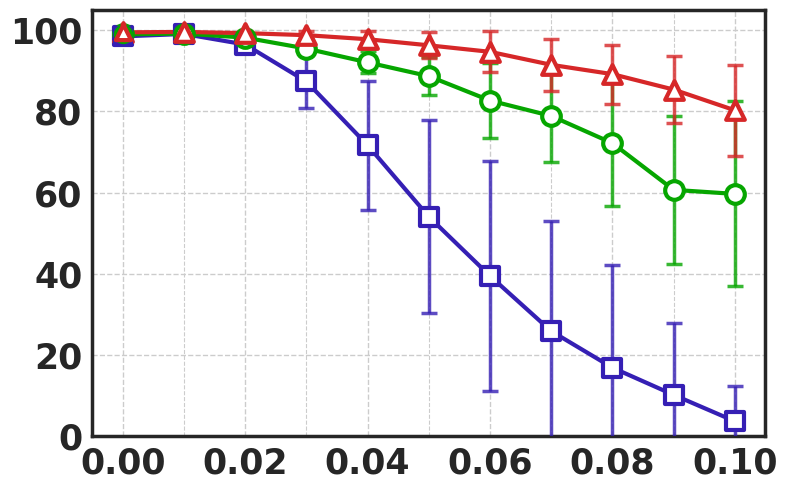

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

# ===== フォントサイズ設定 =====
TICK_SIZE = 25
LABEL_SIZE = 28
LEGEND_SIZE = 22

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    # results_df から直接取得
    df_u = results_df[results_df["unit"] == unit].sort_values("gaussian")

    # gaussian = 0.0 を強調
    if 0.0 in df_u["gaussian"].values:
        y0 = df_u.loc[df_u["gaussian"] == 0.0, "mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    # 折れ線
    plt.plot(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    # マーカー
    plt.scatter(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    # ===== エラーバー =====
    plt.errorbar(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",          # マーカーは描かない
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
        alpha=0.8,
    )

# ===== 軸設定 =====
plt.ylim(0, 105)
plt.xlim(-0.005, 0.105)

plt.xticks(
    np.arange(0.0, 0.11, 0.02),
    fontsize=TICK_SIZE,
    fontweight="bold",
)
plt.yticks(
    np.arange(0, 101, 20),
    fontsize=TICK_SIZE,
    fontweight="bold",
)

# ===== グリッド =====
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

# ===== 枠線 =====
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()


In [4]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/shift"
TOP_K = 10  # 上位k行で平均

def extract_shift(path):
    m = re.search(r"shift([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []

for unit in units:
    pattern = f"{base_path}/u{unit}/shift*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        s = extract_shift(f)
        if s is None:
            continue

        df = pd.read_csv(f)

        # === ここが変更点 ===
        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "shift": s,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df_shift = pd.DataFrame(results)
print(results_df_shift)

    unit  shift  mean_success  std_success
0     64   0.00         0.985     0.007071
1     64   0.01         0.987     0.009487
2     64   0.02         0.973     0.014944
3     64   0.03         0.958     0.021499
4     64   0.04         0.937     0.036530
5     64   0.05         0.911     0.051088
6     64   0.06         0.897     0.055588
7     64   0.07         0.857     0.087946
8     64   0.08         0.830     0.089815
9     64   0.09         0.785     0.111280
10    64   0.10         0.716     0.148039
11   128   0.00         0.992     0.004216
12   128   0.01         0.991     0.007379
13   128   0.02         0.984     0.006992
14   128   0.03         0.980     0.011547
15   128   0.04         0.970     0.010541
16   128   0.05         0.960     0.018856
17   128   0.06         0.941     0.021833
18   128   0.07         0.928     0.041042
19   128   0.08         0.899     0.058775
20   128   0.09         0.872     0.062147
21   128   0.10         0.849     0.088751
22   256   

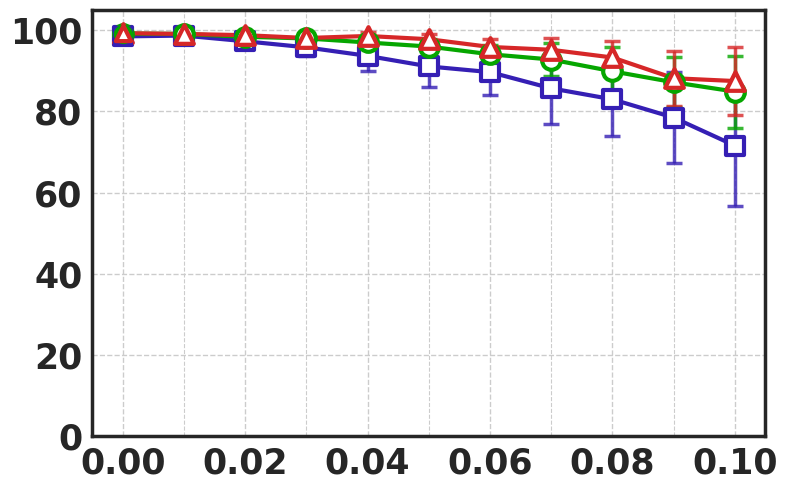

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

# ===== フォントサイズ設定 =====
TICK_SIZE = 25
LABEL_SIZE = 28
LEGEND_SIZE = 22

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    # results_df から直接取得
    df_u = results_df_shift[results_df_shift["unit"] == unit].sort_values("shift")

    # gaussian = 0.0 を強調
    if 0.0 in df_u["shift"].values:
        y0 = df_u.loc[df_u["shift"] == 0.0, "mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    # 折れ線
    plt.plot(
        df_u["shift"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    # マーカー
    plt.scatter(
        df_u["shift"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    # ===== エラーバー =====
    plt.errorbar(
        df_u["shift"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",          # マーカーは描かない
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
        alpha=0.8
    )

# ===== 軸設定 =====
plt.ylim(0, 105)
plt.xlim(-0.005, 0.105)

plt.xticks(
    np.arange(0.0, 0.11, 0.02),
    fontsize=TICK_SIZE,
    fontweight="bold",
)
plt.yticks(
    np.arange(0, 101, 20),
    fontsize=TICK_SIZE,
    fontweight="bold",
)

# ===== グリッド =====
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

# ===== 枠線 =====
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()


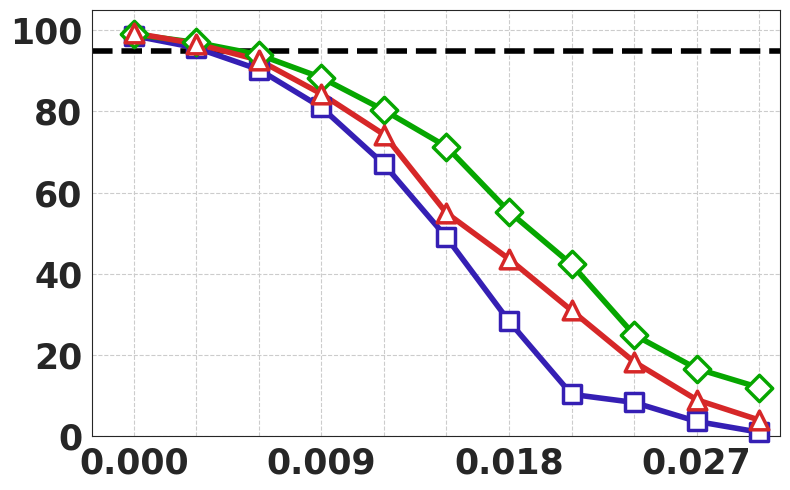

In [6]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker
import seaborn as sns

# --- 描画設定 ---
custom_colors = {
    "u64":  "#351fb4",
    "u128": "#06a600",
    "u256": "#d62728",
}
markers = {
    "u64":  "s",
    "u128": "D",
    "u256": "^",
}

# パラメータ
units = [64, 128, 256]
shifts = np.arange(0.0, 0.031, 0.003).round(3).tolist()
base_path = "/work/robomimic/csv/eval/lift/error/shift"

results = []
for unit in units:
    for s in shifts:
        pattern = f"{base_path}/unit{unit}/shift{s}.csv"
        files = sorted(glob.glob(pattern))
        if not files:
            continue

        df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

        if "seed" in df_all.columns:
            group_col = "seed"
        else:
            df_all["seed"] = df_all["name"].str.extract(r"seed(\d+)").astype(int)
            group_col = "seed"

        # seed ごとの最大 success_rate
        df_max = df_all.loc[df_all.groupby(group_col)["success_rate"].idxmax()]

        # 上位3 seed の平均
        top3 = df_max.nlargest(3, "success_rate")
        mean_success = top3["success_rate"].mean()

        results.append({
            "unit": unit,
            "shift": s,
            "mean_success": mean_success
        })

sns.set_style("white")
results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]]
):
    df_u = results_df[results_df["unit"] == unit]

    if 0.0 in df_u["shift"].values:
        y0 = df_u[df_u["shift"] == 0.0]["mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker, s=120,
            facecolors="white", edgecolors=color,
            linewidths=3, zorder=3
        )

    plt.plot(
        df_u["shift"], df_u["mean_success"] * 100,
        color=color, linewidth=4, zorder=2
    )
    plt.scatter(
        df_u["shift"], df_u["mean_success"] * 100,
        marker=marker, s=180,
        facecolors="white", edgecolors=color,
        linewidths=2.5, zorder=3,clip_on=False
    )

plt.ylim(0, 105)
plt.xticks(np.arange(0.0, 0.031, 0.006), fontsize=25, fontweight="bold")
plt.yticks(np.arange(0, 101, 20), fontsize=25, fontweight="bold")

plt.xlabel("")
plt.ylabel("")
plt.axhline(95, color="black", linestyle="--", linewidth=4, zorder=1)

ax = plt.gca()

# major / minor tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.009))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.003))

# grid（0.003刻み）
ax.grid(which="minor", linestyle="--")
ax.grid(which="major", linestyle="--")
plt.xlim(-0.002, 0.031)

# grid を 0.003 刻みで
ax.grid(linestyle="--")


plt.tight_layout()
plt.show()
